# Fast convolution

So, the english is not very good, I will improve that

In [1]:
import itertools

import sympy as sy
import numpy as np

In [2]:
import fitz

In [3]:
from utils import plot_pdf

In [4]:
doc = fitz.open('tolimieri et al_2013_Algorithms for Discrete Fourier Transform and Convolution.pdf')

The base for this tutorial is the book "Fast Algorithms or Signal Processing" of Blahut.
Is an excellent book but full of examples but, of course, do not explain everything in details.
For that parts I will quote another books and videos from YouTube.

The book puts first all theory and only after that we have a detailed example. To better understanding in this tutorial we have quotes from theory and examples together fallowing the sequence of commands

This example will not work for different vector sizes.

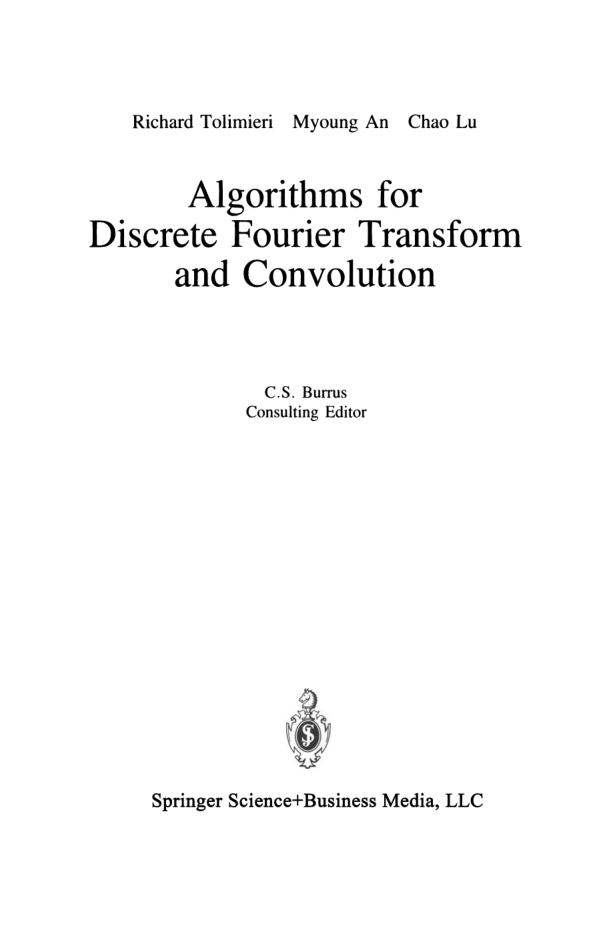

In [5]:
plot_pdf(doc[1], dpi=100)

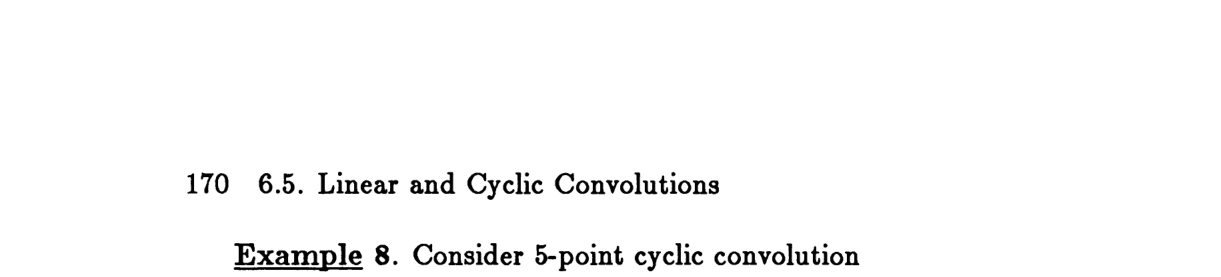

In [9]:
plot_pdf(doc[182], [0, .15])

## Start

Size of vectors

In [10]:
d_num = 5
g_num = 5

Example of vectors for the convolution

In [11]:
d_values = list(range(1, d_num+1))
g_values = list(range(1, g_num+1))
print(d_values, g_values)

[1, 2, 3, 4, 5] [1, 2, 3, 4, 5]


Polynomial degree

In [12]:
d_degree = d_num - 1
g_degree = g_num - 1
print(d_degree, g_degree)

4 4


In [13]:
x = sy.symbols("x")
x

x

In [14]:
di = sy.Matrix(sy.symbols(" ".join(f"d_{i}"for i in range(d_num))))
di

Matrix([
[d_0],
[d_1],
[d_2],
[d_3],
[d_4]])

In [15]:
gi = sy.Matrix(sy.symbols(" ".join(f"g_{i}"for i in range(g_num))))
gi

Matrix([
[g_0],
[g_1],
[g_2],
[g_3],
[g_4]])

In [16]:
dx = sum([i*x**e for e, i in enumerate(di)])
dx

d_0 + d_1*x + d_2*x**2 + d_3*x**3 + d_4*x**4

In [17]:
gx = sum([i*x**e for e, i in enumerate(gi)])
gx

g_0 + g_1*x + g_2*x**2 + g_3*x**3 + g_4*x**4

In [18]:
sx = gx*dx
sx

(d_0 + d_1*x + d_2*x**2 + d_3*x**3 + d_4*x**4)*(g_0 + g_1*x + g_2*x**2 + g_3*x**3 + g_4*x**4)

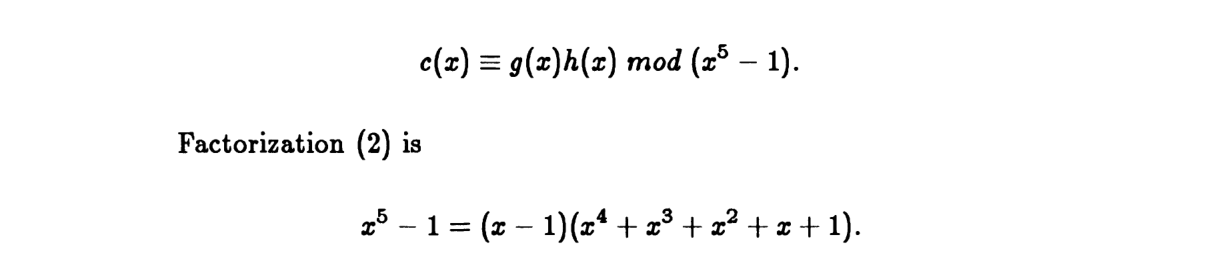

In [19]:
plot_pdf(doc[182], [0.15, 0.3])

In [20]:
mk = sy.Matrix([x-1, x**4+x**3+x**2+x+1])
mk

Matrix([
[                     x - 1],
[x**4 + x**3 + x**2 + x + 1]])

## Input polynomials

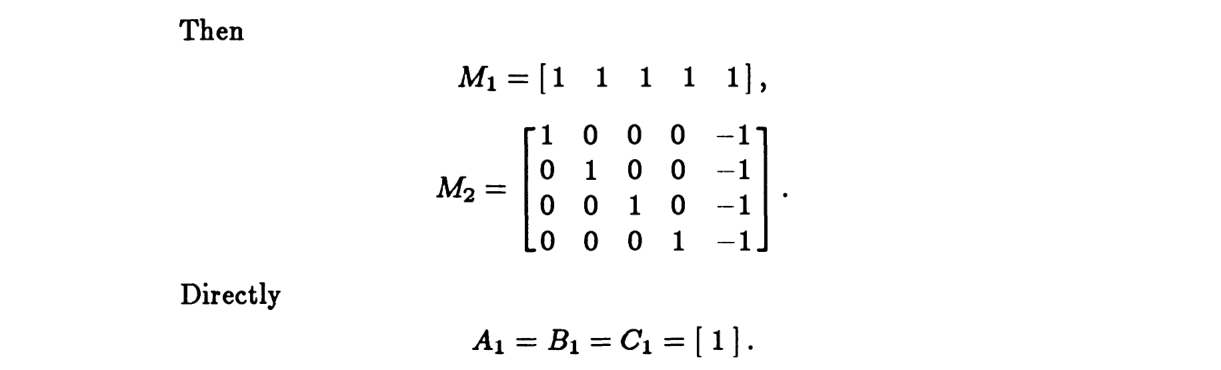

In [21]:
plot_pdf(doc[182], [.3, .5])

$d_k$ and $g_k$ undergo polynomial division and we only get the remainder

In [22]:
gk = sy.Matrix([sy.rem(gx, q, domain ='ZZ') for q in mk])
gk

Matrix([
[                                          g_0 + g_1 + g_2 + g_3 + g_4],
[g_0 + g_1*x + g_2*x**2 + g_3*x**3 - g_4*x**3 - g_4*x**2 - g_4*x - g_4]])

In [53]:
dk = sy.Matrix([sy.rem(dx, q, domain ='ZZ') for q in mk])
dk

Matrix([
[                                          d_0 + d_1 + d_2 + d_3 + d_4],
[d_0 + d_1*x + d_2*x**2 + d_3*x**3 - d_4*x**3 - d_4*x**2 - d_4*x - d_4]])

In [54]:
a0_lst = [[d.coeff(c, 1) for c in di] for d in dk[:-1]]
a0_lst

[[1, 1, 1, 1, 1]]

In [55]:
a20_lst = [dk[1].subs({x:0}).coeff(c, 1) for c in di]
a20_lst

[1, 0, 0, 0, -1]

In [56]:
a21_lst = [dk[1].coeff(c, 1).coeff(x, 1) for c in di]
a21_lst

[0, 1, 0, 0, -1]

In [57]:
a22_lst = [dk[1].coeff(c, 1).coeff(x**2, 1) for c in di]
a22_lst

[0, 0, 1, 0, -1]

In [58]:
a23_lst = [dk[1].coeff(c, 1).coeff(x**3, 1) for c in di]
a23_lst

[0, 0, 0, 1, -1]

In [62]:
a0_mtx = sy.Matrix(np.vstack([a0_lst, a20_lst, a21_lst, a22_lst, a23_lst]))
a0_mtx

Matrix([
[1, 1, 1, 1,  1],
[1, 0, 0, 0, -1],
[0, 1, 0, 0, -1],
[0, 0, 1, 0, -1],
[0, 0, 0, 1, -1]])

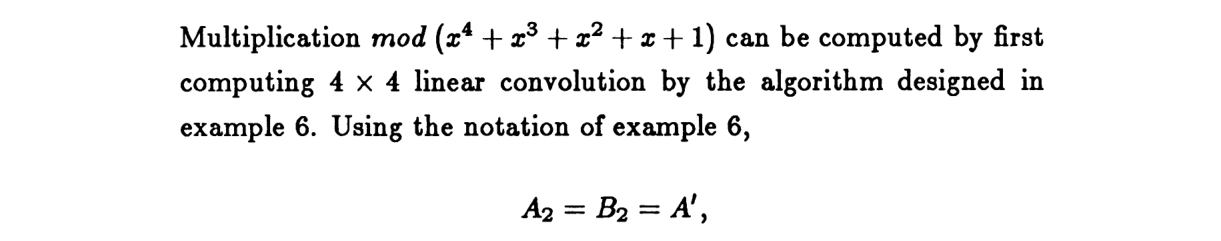

In [60]:
plot_pdf(doc[182], [.5, .63])

In [29]:
di2 = sy.Matrix(sy.symbols(" ".join(f"d_{i}^(2)"for i in range(2))))
di2

Matrix([
[d_0^(2)],
[d_1^(2)]])

In [30]:
gi2 = sy.Matrix(sy.symbols(" ".join(f"g_{i}^(2)"for i in range(2))))
gi2

Matrix([
[g_0^(2)],
[g_1^(2)]])

Just defining values of matrices, I don't know where this values come from.

In [92]:
a2_mtx = sy.Matrix([[1, 0], [1, -1], [0, 1]])
a2_mtx

Matrix([
[1,  0],
[1, -1],
[0,  1]])

In [27]:
b2_mtx = sy.Matrix([[1, 0], [1, -1], [0, 1]])
b2_mtx

Matrix([
[1,  0],
[1, -1],
[0,  1]])

In [31]:
bg2_mtx = sy.diag(*(b2_mtx*sy.Matrix(gi2)).tolist())
bg2_mtx

Matrix([
[g_0^(2),                 0,       0],
[      0, g_0^(2) - g_1^(2),       0],
[      0,                 0, g_1^(2)]])

In [102]:
c2_mtx = sy.Matrix([
    [1, 0, -1],
    [1, -1, 1],
])
c2_mtx

Matrix([
[1,  0, -1],
[1, -1,  1]])

In [33]:
sy.MatMul(c2_mtx, bg2_mtx, a2_mtx, sy.Matrix(di2), evaluate=True)

Matrix([
[d_0^(2)*g_0^(2) - d_1^(2)*g_1^(2)],
[d_0^(2)*g_1^(2) + d_1^(2)*g_0^(2)]])

## Output or inverse polynomial

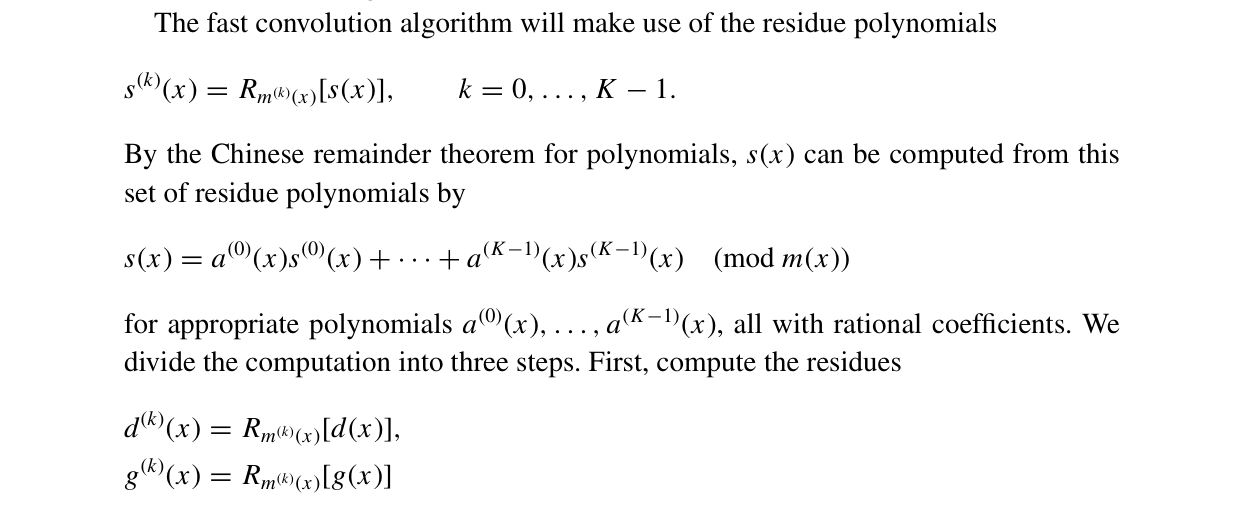

In [32]:
plot_pdf(doc[171], [0.65, .92])

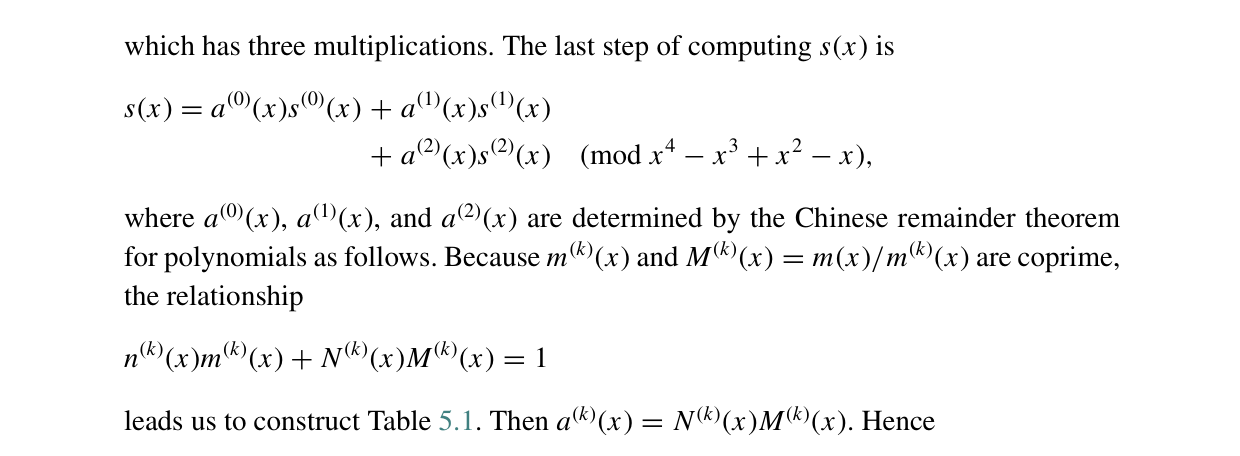

In [33]:
plot_pdf(doc[175], [.4, .64])

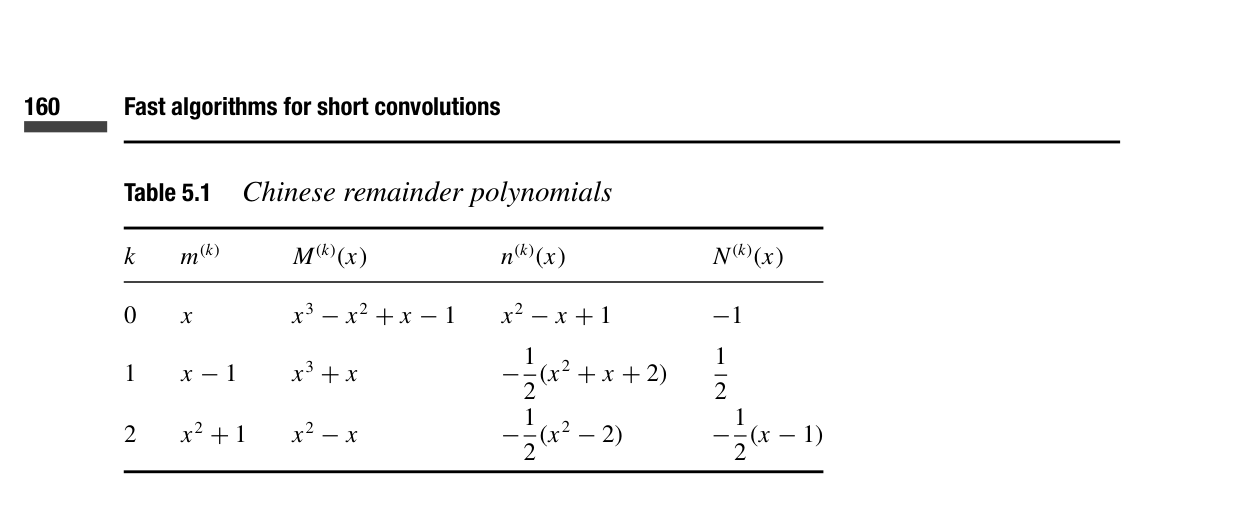

In [34]:
plot_pdf(doc[175], [0, .27])

$m^{(k)}$ is `mk`

$M^{(k)}$ is `mmk`

$N^{(k)}$ is `nnk`

In [27]:
mk

Matrix([
[                     x - 1],
[x**4 + x**3 + x**2 + x + 1]])

In [28]:
mmk = sy.Matrix([sy.expand(np.prod(d)) for d in itertools.combinations(reversed(mk), len(mk)-1)])
mmk

Matrix([
[x**4 + x**3 + x**2 + x + 1],
[                     x - 1]])

Put quotient and remainder in $nm+NM=1$ format

In [29]:
mmk_div = [sy.div(dv, ds, domain ='ZZ') for dv, ds in zip(mmk, mk)]

In [30]:
mmk_quo = sy.Matrix([x[0] for x in mmk_div])
mmk_quo

Matrix([
[x**3 + 2*x**2 + 3*x + 4],
[                      0]])

In [31]:
mmk_rem = sy.Matrix([x[1] for x in mmk_div])
mmk_rem

Matrix([
[    5],
[x - 1]])

Here we see the first differences or problems to replicate the examples from book, $n^{(2)}$ and $N^{(2)}$ are different.

In [32]:
nnk = sy.Matrix([1/z for z in mmk_rem])
nnk

Matrix([
[      1/5],
[1/(x - 1)]])

To get the correct $N^{(2)}$ and $n^{(2)}$, how the video above explain, execute:

$$M^{(2)} = m^{(2)}Q^{(2)} + R^{(2)}$$

$$R^{(2)} = M^{(2)}q^{(2)} + r^{(2)}$$

$$n^{(2)} = \frac{q^{(2)}}{r^{(2)}}$$

$$N^{(2)} =\frac{q^{(2)} + Q^{(2)}}{r^{(2)}}$$

I believe all these operations are necessary because the remainder $R^{(2)}$ have the $x$ variable. If this remainder not have a variable but a constant, like 5.6 section of book, this not will be necessary.

In [40]:
mmk2_quo, mmk2_rem = sy.div(mk[-1], mmk_rem[-1], domain ='ZZ')

In [41]:
mmk2_quo

x

In [42]:
mmk2_rem

1

If $N$ has $x$ variable, it needs to be positive

In [79]:
nnk2 = mmk2_quo/mmk2_rem
nnk2 = nnk2*(-1) if nnk2.coeff(x).is_negative else nnk2
nnk2

x

In [44]:
nk2 = (mmk_quo[-1] + mmk2_quo)/mmk2_rem
nk2 = nk2*(-1) if nk2.coeff(x).is_negative else nk2
nk2

x

Correct $n_{(x)}^{(k)}$

In [80]:
sy.Matrix([q * r * (-1) for q, r in zip(mmk_quo[:-1], nnk[:-1])] + [nk2])


Matrix([
[-x],
[ x]])

Correct $N_{(x)}^{(k)}$

In [81]:
sy.Matrix(nnk[:-1] + [nnk2])

Matrix([
[1],
[x]])

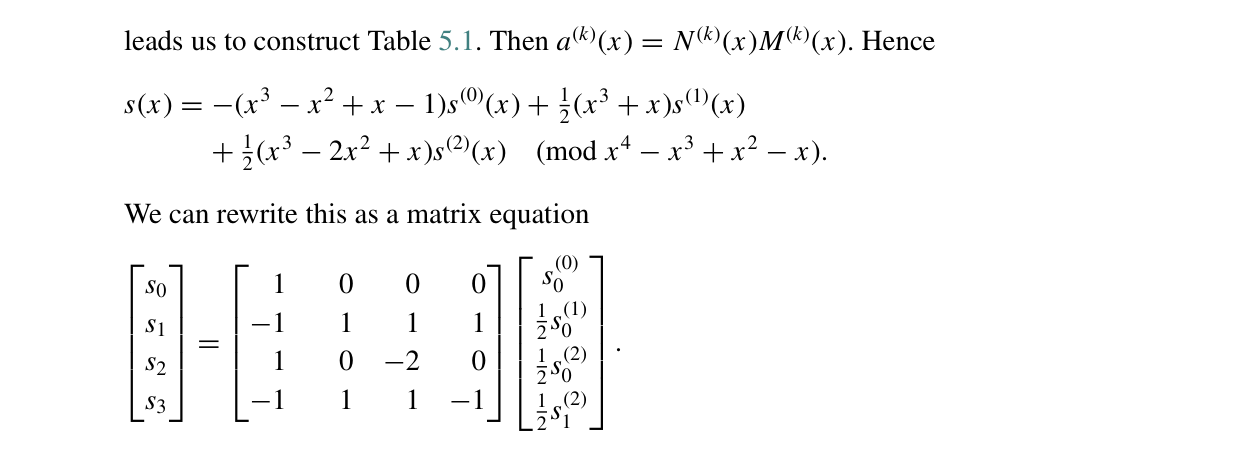

In [49]:
plot_pdf(doc[175], [0.6, .84])

In the next video $S^{(2)} = M^{(2)} \times N^{(2)}$

$S^{(2)} = S_{0}^{(2)} + S_{1}^{(2)}x$

And $S_{1}^{(2)}$ is the remainder of $M(x)$ by $S_{0}^{(2)}x$ or:

$$M(x)$ = $S_{0}^{(2)}x$Q + $S_{1}^{(2)}$$

 I believe this is because $s^{(2)}$ is degree $3$, the maximum, so when $s^{(2)}$ is multiplicated by $x$ the degree will be $4$ extrapolating the maximal polynomial degree of the function. This is different from 5.6 example where $s^{(2)}$ is degree $2$, not the maximum.


I don't multiply the  $M^{(2)}$ by $N^{(2)}$ but by the quotient $q_{m}^{(2)}$ $m^{(2)} \times $
by (mmk_rem[-1] | mmk, mk)

In [82]:
c20_mtx = sy.expand(mmk[-1]*mmk2_quo)
c20_mtx

x**2

In [83]:
c21_mtx = sy.rem(np.prod(mk), sy.expand(c20_mtx*x), domain ='QQ')
c21_mtx

x

Getting $s_{0}^{(2)}$ and $s_{1}^{(2)}$ is too confusing. Maybe help studying quadratic residues.

## Put all together

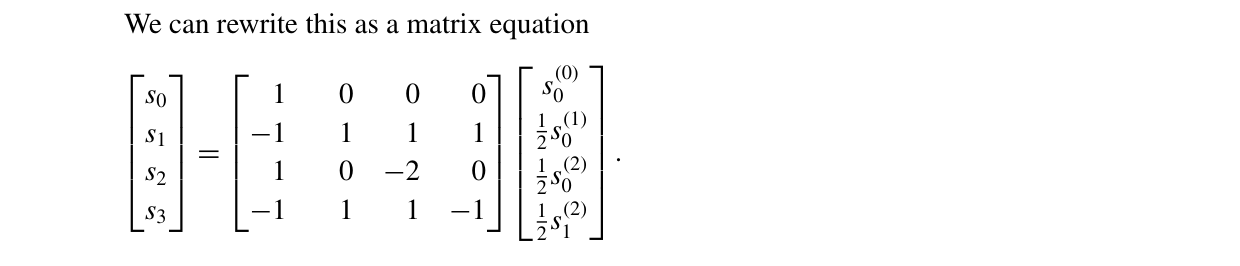

In [53]:
plot_pdf(doc[175], [0.7, .84])

Important: the signals of the $C$ matrix are inverted.
I multiply $N^{(k)}$ matrix by $G$ and not by $C$.
In books the constants of $N^{(k)}$ go to $G$, and the signals go to $C$.
In this implementation all go to $G$.

In [84]:
mmk_new = sy.Matrix(mmk[:-1] + [c20_mtx] + [c21_mtx])
mmk_new

Matrix([
[x**2 + 1],
[    x**2],
[       x]])

In [85]:
c0_mtx = sy.Matrix([[d.coeff(x, c) for d in mmk_new] for c in range(len(np.prod(mk).as_poly().all_coeffs())-1)])
c0_mtx

Matrix([
[1, 0, 0],
[0, 0, 1],
[1, 1, 0]])

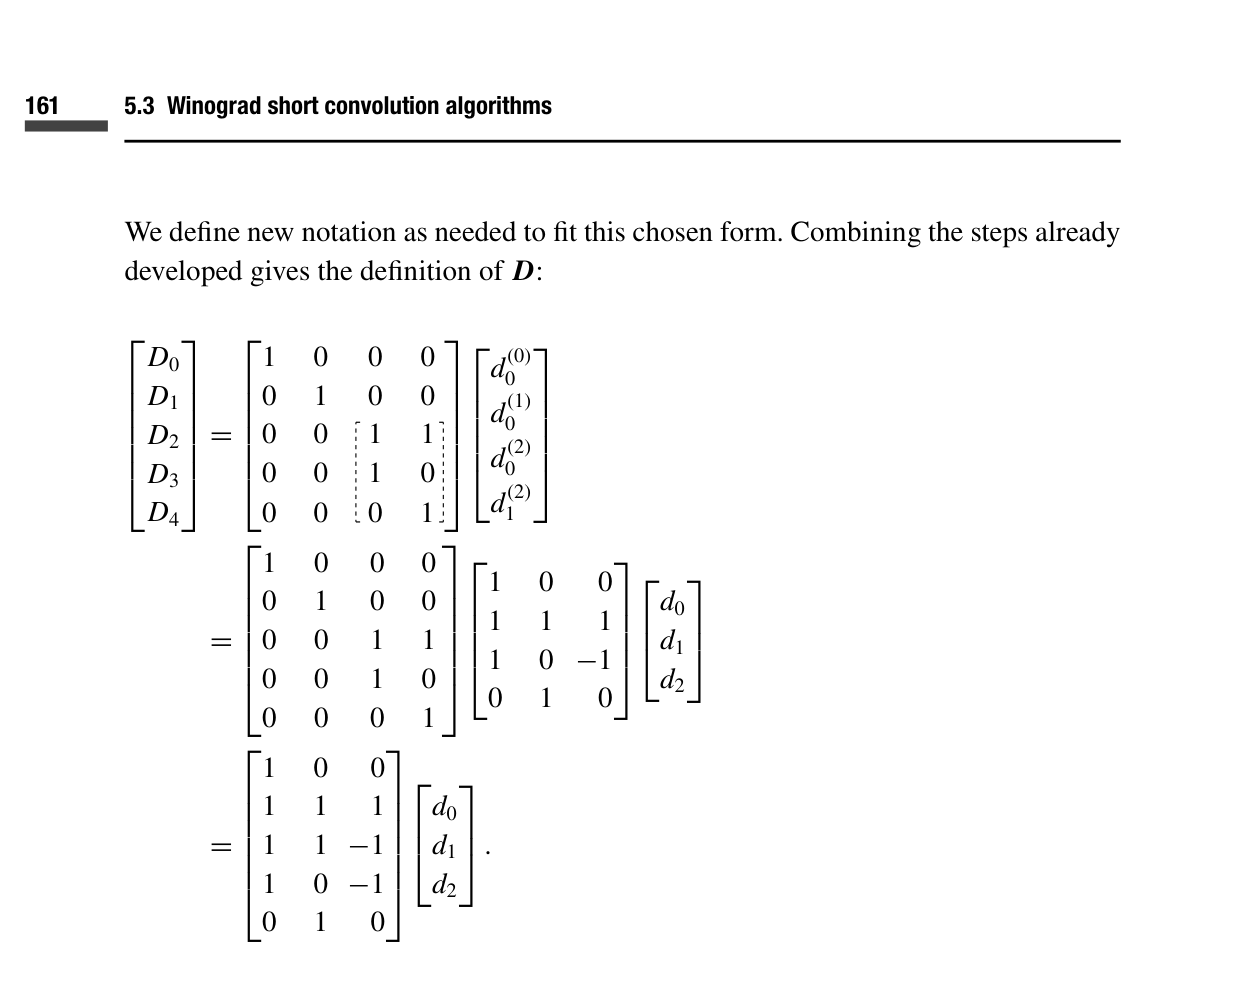

In [56]:
plot_pdf(doc[176], [0, .52])

In [46]:
dk

Matrix([
[                                          d_0 + d_1 + d_2 + d_3 + d_4],
[d_0 + d_1*x + d_2*x**2 + d_3*x**3 - d_4*x**3 - d_4*x**2 - d_4*x - d_4]])

In [95]:
a2e_mtx = sy.Matrix(sy.diag(sy.eye(1), a2_mtx))
a2e_mtx

Matrix([
[1, 0,  0],
[0, 1,  0],
[0, 1, -1],
[0, 0,  1]])

In [97]:
a_mtx = a2e_mtx * a0_mtx
a_mtx

Matrix([
[1,  0,  0],
[1,  0, -1],
[1, -1, -1],
[0,  1,  0]])

In [120]:
bg_mtx = sy.diag(*(a_mtx*gi).tolist())
bg_mtx

Matrix([
[g_0,         0,               0,   0],
[  0, g_0 - g_2,               0,   0],
[  0,         0, g_0 - g_1 - g_2,   0],
[  0,         0,               0, g_1]])

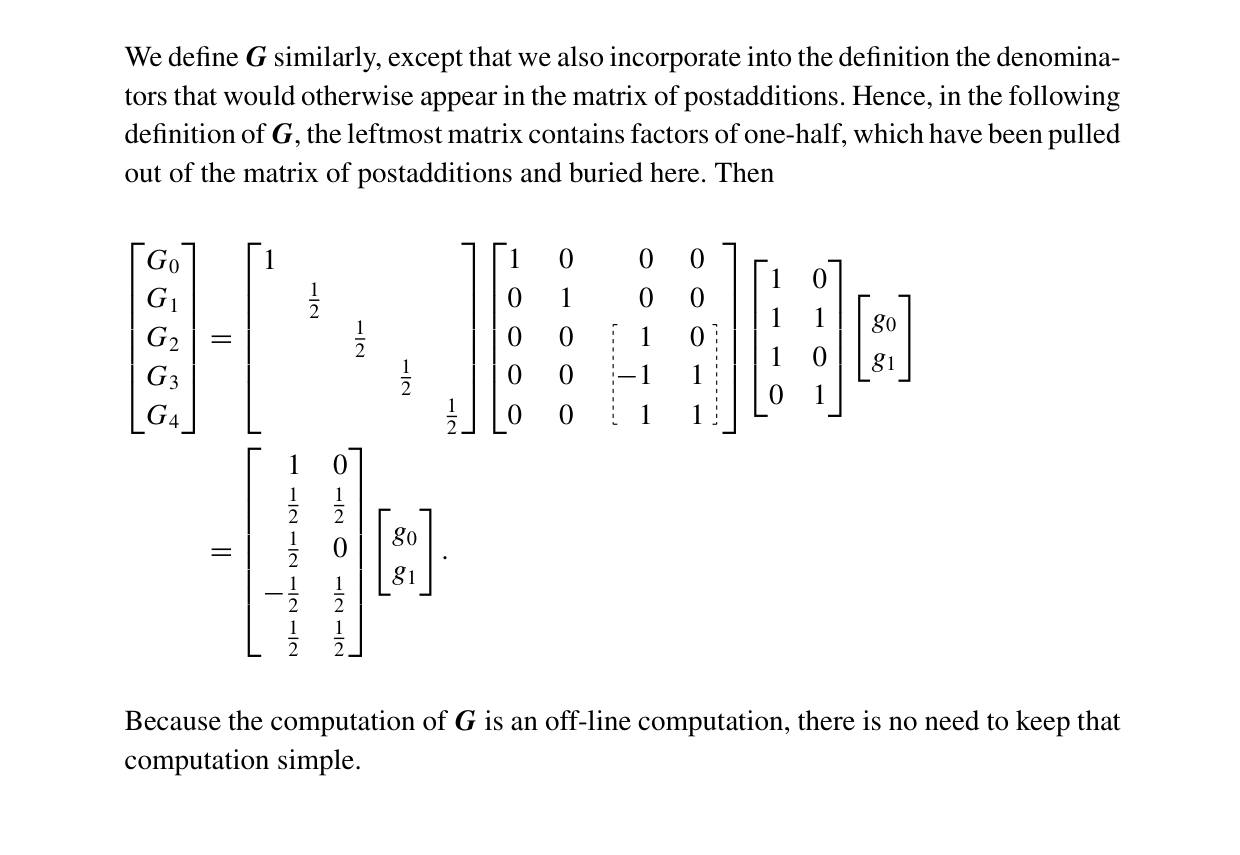

In [63]:
plot_pdf(doc[176], [.5, .95])

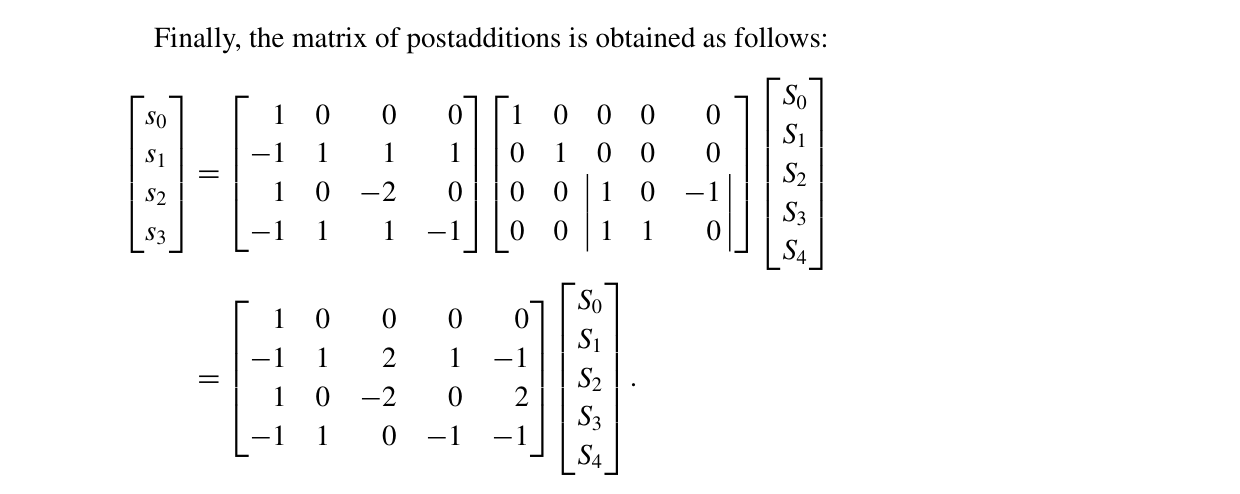

In [72]:
plot_pdf(doc[177], [.36, .62])

In [103]:
c2e_mtx = sy.Matrix(sy.diag(sy.eye(1), c2_mtx))
c2e_mtx

Matrix([
[1, 0,  0,  0],
[0, 1,  0, -1],
[0, 1, -1,  1]])

In [106]:
c_mtx = c0_mtx * c2e_mtx
c_mtx

Matrix([
[1, 0,  0,  0],
[0, 1, -1,  1],
[1, 1,  0, -1]])

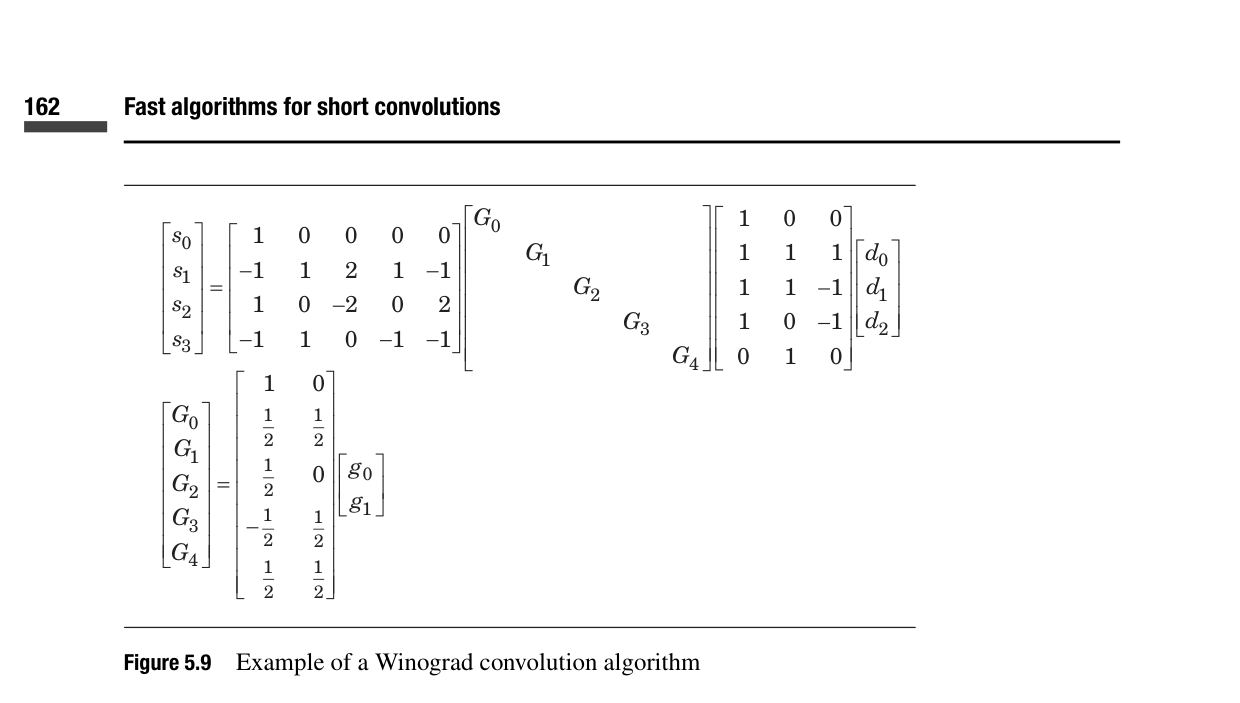

In [75]:
plot_pdf(doc[177], [0, .37])

In [121]:
s = sy.MatMul(c_mtx, bg_mtx, a_mtx, di)
s

Matrix([
[1, 0,  0,  0],
[0, 1, -1,  1],
[1, 1,  0, -1]])*Matrix([
[g_0,         0,               0,   0],
[  0, g_0 - g_2,               0,   0],
[  0,         0, g_0 - g_1 - g_2,   0],
[  0,         0,               0, g_1]])*Matrix([
[1,  0,  0],
[1,  0, -1],
[1, -1, -1],
[0,  1,  0]])*Matrix([
[d_0],
[d_1],
[d_2]])

## Example

In [122]:
subs = {k[0]: v for k, v in zip(di.tolist()+gi.tolist(), d_values + g_values)}
subs

{d_0: 1, d_1: 2, d_2: 3, g_0: 1, g_1: 2, g_2: 3}

In [123]:
si = s.subs(subs)
si

Matrix([
[1, 0,  0,  0],
[0, 1, -1,  1],
[1, 1,  0, -1]])*Matrix([
[1,  0,  0, 0],
[0, -2,  0, 0],
[0,  0, -4, 0],
[0,  0,  0, 2]])*Matrix([
[1,  0,  0],
[1,  0, -1],
[1, -1, -1],
[0,  1,  0]])*Matrix([
[1],
[2],
[3]])

In [124]:
sy.expand(sx)

d_0*g_0 + d_0*g_1*x + d_0*g_2*x**2 + d_1*g_0*x + d_1*g_1*x**2 + d_1*g_2*x**3 + d_2*g_0*x**2 + d_2*g_1*x**3 + d_2*g_2*x**4

Let's compare the output polynomial matrix from direct and winograd method

In [125]:
sy.Matrix(np.convolve(np.array(di).reshape(-1), np.array(gi).reshape(-1)))

Matrix([
[                    d_0*g_0],
[          d_0*g_1 + d_1*g_0],
[d_0*g_2 + d_1*g_1 + d_2*g_0],
[          d_1*g_2 + d_2*g_1],
[                    d_2*g_2]])

In [126]:
se = sy.MatMul(c_mtx, bg_mtx, a_mtx, di, evaluate=True)
se

Matrix([
[                                       d_0*g_0],
[           d_0*g_1 + d_1*(g_0 - g_2) - d_2*g_1],
[d_0*(2*g_0 - g_2) - d_1*g_1 + d_2*(-g_0 + g_2)]])

Comparing numerical outputs from direct and winograd method

In [127]:
sy.Matrix(np.convolve(d_values, g_values))

Matrix([
[ 1],
[ 4],
[10],
[12],
[ 9]])

In [128]:
se.subs(subs)

Matrix([
[ 1],
[-8],
[ 1]])